In [1]:
!pip install vncorenlp

In [2]:
import warnings
import sys
import os
import gc
import re
import pickle
import json
import multiprocessing
from collections import Counter
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence
from torch.cuda.amp import autocast, GradScaler           # ← MỚI: Mixed Precision
from torch.optim.lr_scheduler import ReduceLROnPlateau

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from vncorenlp import VnCoreNLP
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support, f1_score
)
from sklearn.utils.class_weight import compute_class_weight
from gensim.models import Word2Vec
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch version: 2.8.0+cu126


/usr/local/lib/python3.12/dist-packages/google/cloud/aiplatform/models.py:52: FutureWarning: Support for google-cloud-storage < 3.0.0 will be removed in a future version of google-cloud-aiplatform. Please upgrade to google-cloud-storage >= 3.0.0.
  from google.cloud.aiplatform.utils import gcs_utils


In [3]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.benchmark = True       # Tự chọn CUDA kernel nhanh nhất
    torch.backends.cudnn.deterministic = False  # Tắt deterministic để tăng tốc
    n_gpu = torch.cuda.device_count()
    print(f"\n✅ GPU Available! ({n_gpu} GPU(s))")
    for i in range(n_gpu):
        name = torch.cuda.get_device_name(i)
        vram = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"   GPU {i}: {name} | VRAM: {vram:.1f} GB")
else:
    print("\n⚠️  Không tìm thấy GPU → Dùng CPU (chậm hơn ~20x)")

print(f"Device: {device}")

# DataLoader workers
NUM_WORKERS = min(2, multiprocessing.cpu_count())
PIN_MEMORY  = torch.cuda.is_available()
print(f"DataLoader workers: {NUM_WORKERS} | pin_memory: {PIN_MEMORY}")

print("\n" + "="*80)
print("Installation complete")


✅ GPU Available! (2 GPU(s))
   GPU 0: Tesla T4 | VRAM: 15.6 GB
   GPU 1: Tesla T4 | VRAM: 15.6 GB
Device: cuda
DataLoader workers: 2 | pin_memory: True

Installation complete


In [4]:
print("\n" + "="*80)
print("INITIALIZING VnCoreNLP")
print("="*80)

VNCORENLP_PATH = "/kaggle/input/chiuluon/VnCoreNLP-master/VnCoreNLP-1.2.jar"
print(f"VnCoreNLP JAR path: {VNCORENLP_PATH}")

if not os.path.isfile(VNCORENLP_PATH):
    raise FileNotFoundError(f"Cannot find jar at {VNCORENLP_PATH}")

print("Initializing VnCoreNLP...")
rdrsegmenter = VnCoreNLP(
    VNCORENLP_PATH,
    annotators="wseg",
    max_heap_size='-Xmx1g'
)
print("VnCoreNLP initialized successfully!")

# Test
print("\nTest:")
print(" ->", rdrsegmenter.tokenize("Tôi đang học xử lý ngôn ngữ tự nhiên"))


INITIALIZING VnCoreNLP
VnCoreNLP JAR path: /kaggle/input/chiuluon/VnCoreNLP-master/VnCoreNLP-1.2.jar
Initializing VnCoreNLP...
VnCoreNLP initialized successfully!

Test:
 -> [['Tôi', 'đang', 'học', 'xử_lý', 'ngôn_ngữ_tự_nhiên']]


In [5]:
print("\n" + "="*80)
print("LOADING STOPWORDS")
print("="*80)

STOPWORDS_PATH = "/kaggle/input/stopword/vn_stopwords.txt"
try:
    with open(STOPWORDS_PATH, 'r', encoding='utf-8') as f:
        VIETNAMESE_STOPWORDS = set(line.strip() for line in f if line.strip())
    print(f"Loaded {len(VIETNAMESE_STOPWORDS)} stopwords from file")
except FileNotFoundError:
    VIETNAMESE_STOPWORDS = {
        'và', 'của', 'có', 'trong', 'được', 'cho', 'là', 'với', 'các', 'không',
        'này', 'đã', 'những', 'tại', 'hay', 'để', 'từ', 'một', 'như', 'người',
        'về', 'ra', 'đến', 'năm', 'họ', 'khi', 'cũng', 'theo', 'sau', 'hoặc',
        'bởi', 'thì', 'nếu', 'đó', 'sẽ', 'bạn', 'chúng', 'nó', 'nhiều', 'đều',
        'còn', 'vì', 'nên', 'thế', 'mà', 'cả', 'thêm', 'lại', 'vào', 'do',
        'rất', 'cùng', 'lên', 'việc', 'đang', 'làm', 'nay', 'ngày', 'giờ'
    }
    print(f"Using {len(VIETNAMESE_STOPWORDS)} default stopwords")

print(f"Sample: {list(VIETNAMESE_STOPWORDS)[:10]}")


LOADING STOPWORDS
Loaded 1942 stopwords from file
Sample: ['gây_giống', 'qua_chuyện', 'có_phải', 'tuốt_tuột', 'chớ', 'giảm_thấp', 'tọt', 'tuy_đã', 'toẹt', 'tốt_bạn']


In [6]:
print("\n" + "="*80)
print("LOADING DATA")
print("="*80)

DATA_PATH = "/kaggle/input/final-data/laodong_all_news_with_split.csv"
print(f"Loading from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)
print(f"\nLoaded {len(df):,} rows")
print(f"Columns: {list(df.columns)}")


LOADING DATA
Loading from: /kaggle/input/final-data/laodong_all_news_with_split.csv

Loaded 6,000 rows
Columns: ['url', 'title', 'content', 'word_count', 'content_hash', 'class', 'is_test']



EXPLORATORY DATA ANALYSIS

1. Dataset Info:
   Rows: 6,000
   Columns: 7
   Memory: 32.75 MB

2. Missing Values:
   No missing values

3. Duplicates: 0

4. Class Distribution:
class
kinh-doanh    1500
the-gioi      1500
cong-nghe     1500
the-thao      1500
Name: count, dtype: int64

5. Text Length Statistics:
   Mean: 526.3 words
   Median: 478.0 words
   Min: 151 words
   Max: 13781 words
   Texts > 512 words: 2,588 (43.1%)

6. Generating WordClouds for 4 classes...
   Generating WordCloud for: kinh-doanh
   Generating WordCloud for: the-gioi
   Generating WordCloud for: cong-nghe
   Generating WordCloud for: the-thao


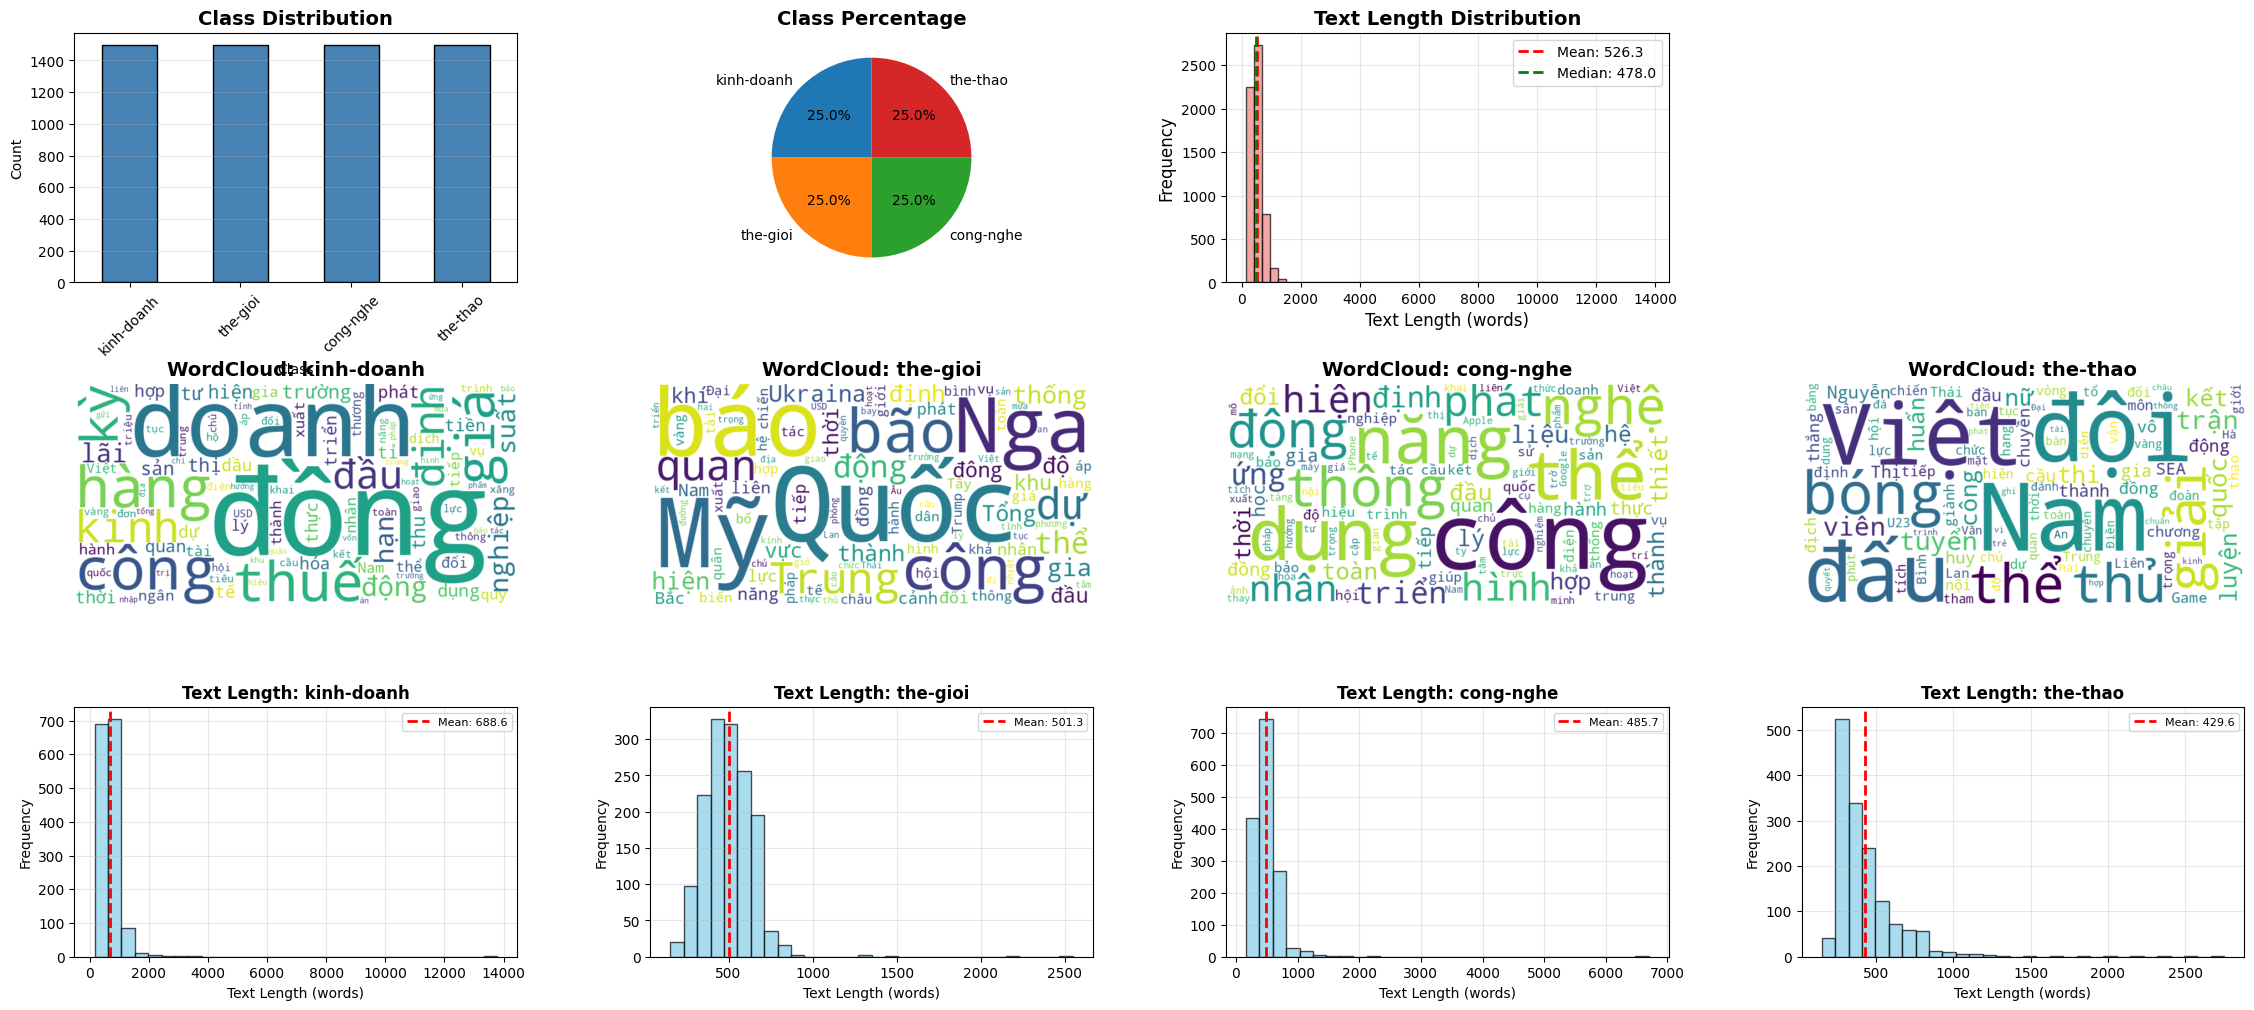


EDA complete - saved to eda_analysis.png


In [7]:
print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80)

print(f"\n1. Dataset Info:")
print(f"   Rows: {len(df):,}")
print(f"   Columns: {len(df.columns)}")
print(f"   Memory: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

print(f"\n2. Missing Values:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(pd.DataFrame({
        'Missing': missing[missing > 0],
        'Percentage': (missing[missing > 0] / len(df) * 100).round(2)
    }))
else:
    print("   No missing values")

print(f"\n3. Duplicates: {df.duplicated().sum():,}")

print(f"\n4. Class Distribution:")
class_counts = df['class'].value_counts()
print(class_counts)

classes    = df['class'].unique()
num_classes_eda = len(classes)
ncols      = max(3, num_classes_eda)

fig = plt.figure(figsize=(7 * ncols, 12))
gs  = fig.add_gridspec(3, ncols, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
class_counts.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Class')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
class_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
ax2.set_title('Class Percentage', fontsize=14, fontweight='bold')
ax2.set_ylabel('')

ax3 = fig.add_subplot(gs[0, 2])
text_lengths = df['content'].str.split().str.len()
ax3.hist(text_lengths, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
ax3.axvline(text_lengths.mean(),   color='red',   linestyle='--', linewidth=2,
            label=f'Mean: {text_lengths.mean():.1f}')
ax3.axvline(text_lengths.median(), color='green', linestyle='--', linewidth=2,
            label=f'Median: {text_lengths.median():.1f}')
ax3.set_xlabel('Text Length (words)', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('Text Length Distribution', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

print(f"\n5. Text Length Statistics:")
print(f"   Mean: {text_lengths.mean():.1f} words")
print(f"   Median: {text_lengths.median():.1f} words")
print(f"   Min: {text_lengths.min()} words")
print(f"   Max: {text_lengths.max()} words")
print(f"   Texts > 512 words: {(text_lengths > 512).sum():,} ({(text_lengths > 512).sum()/len(text_lengths)*100:.1f}%)")

font_path = None
print(f"\n6. Generating WordClouds for {num_classes_eda} classes...")

for idx, class_name in enumerate(classes):
    print(f"   Generating WordCloud for: {class_name}")
    class_texts   = df[df['class'] == class_name]['content'].dropna()
    combined_text = ' '.join(class_texts.astype(str))
    wordcloud = WordCloud(
        width=800, height=400, background_color='white',
        colormap='viridis', max_words=100, relative_scaling=0.5,
        min_font_size=10, font_path=font_path,
        stopwords=VIETNAMESE_STOPWORDS, collocations=False
    ).generate(combined_text)
    ax = fig.add_subplot(gs[1, idx])
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f'WordCloud: {class_name}', fontsize=14, fontweight='bold')
    ax.axis('off')

for idx, class_name in enumerate(classes):
    ax = fig.add_subplot(gs[2, idx])
    class_data          = df[df['class'] == class_name]
    class_text_lengths  = class_data['content'].str.split().str.len()
    ax.hist(class_text_lengths, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax.axvline(class_text_lengths.mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {class_text_lengths.mean():.1f}')
    ax.set_xlabel('Text Length (words)', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'Text Length: {class_name}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\nEDA complete - saved to eda_analysis.png")

In [8]:
print("\n" + "="*80)
print("DEFINING PREPROCESSING FUNCTIONS")
print("="*80)

def clean_text(text, remove_stopwords=True):
    """Clean Vietnamese text - Preserves abbreviations"""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d{10,}', '', text)
    text = re.sub(r'<[^>]+>', '', text)

    abbreviation_pattern = r'\b([A-ZĐÀÁẢÃẠĂẰẮẲẴẶÂẦẤẨẪẬÈÉẺẼẸÊỀẾỂỄỆÌÍỈĨỊÒÓỎÕỌÔỒỐỔỖỘƠỜỚỞỠỢÙÚỦŨỤƯỪỨỬỮỰỲÝỶỸỴ]{2,})\b'
    abbreviations = re.findall(abbreviation_pattern, text.upper())

    abbr_map = {}
    for i, abbr in enumerate(set(abbreviations)):
        placeholder = f"__ABBR{i}__"
        abbr_map[placeholder] = abbr.lower()
        text = re.sub(r'\b' + re.escape(abbr) + r'\b', placeholder, text, flags=re.IGNORECASE)

    text = re.sub(
        r'[^\w\sàáảãạăằắẳẵặâầấẩẫậèéẻẽẹêềếểễệìíỉĩịòóỏõọôồốổỗộơờớởỡợùúủũụưừứửữựỳýỷỹỵđ_]',
        ' ', text
    )
    text = re.sub(r'\b\d+\b', '', text)
    text = re.sub(r'\b(?!__)[a-zàáảãạăằắẳẵặâầấẩẫậèéẻẽẹêềếểễệìíỉĩịòóỏõọôồốổỗộơờớởỡợùúủũụưừứửữựỳýỷỹỵđ]\b', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    for placeholder, original in abbr_map.items():
        text = text.replace(placeholder, original)

    if remove_stopwords:
        words = text.split()
        words = [w for w in words if (w not in VIETNAMESE_STOPWORDS or len(w) <= 3) and len(w) > 1]
        text  = ' '.join(words)

    return text.strip()


def tokenize_vncorenlp(text, annotator):
    """Tokenize using VnCoreNLP"""
    if not text or pd.isna(text) or len(str(text).strip()) == 0:
        return ""
    try:
        sentences = annotator.tokenize(str(text))
        tokens = []
        for sentence in sentences:
            tokens.extend(sentence)
        return ' '.join(tokens)
    except Exception as e:
        return str(text)

print("Preprocessing functions ready")



DEFINING PREPROCESSING FUNCTIONS
Preprocessing functions ready


In [9]:
print("\n" + "="*80)
print("PROCESSING DATA WITH VnCoreNLP")
print("="*80)

df_clean = df[df['content'].notna() & (df['content'].str.len() > 0)].copy()
df_clean.reset_index(drop=True, inplace=True)
print(f"Processing {len(df_clean):,} texts...")

# Step 1: Clean
print("\nStep 1/2: Cleaning text...")
tqdm.pandas(desc="Cleaning")
df_clean['content_cleaned'] = df_clean['content'].progress_apply(
    lambda x: clean_text(x, remove_stopwords=True)
)

# Step 2: Tokenize
print("\nStep 2/2: VnCoreNLP Tokenization...")
tokenized_texts = []
errors = 0
for idx, text in tqdm(enumerate(df_clean['content_cleaned']),
                      total=len(df_clean), desc="Tokenizing"):
    try:
        tokenized = tokenize_vncorenlp(text, rdrsegmenter)
        tokenized_texts.append(tokenized)
    except Exception as e:
        if errors < 3:
            print(f"\n   Warning: Error at {idx}: {str(e)[:50]}")
        tokenized_texts.append("")
        errors += 1

df_clean['content_tokenized'] = tokenized_texts
print(f"\nTokenization complete! Errors: {errors} ({errors/len(df_clean)*100:.2f}%)")

# Remove empty
initial   = len(df_clean)
df_clean  = df_clean[df_clean['content_tokenized'].str.len() > 0].copy()
df_clean.reset_index(drop=True, inplace=True)
removed   = initial - len(df_clean)
print(f"Removed: {removed:,} | Final: {len(df_clean):,}")

text_lengths = df_clean['content_tokenized'].str.split().str.len()
print(f"\nText Length Statistics:")
print(f"   Mean: {text_lengths.mean():.1f} | Median: {text_lengths.median():.1f}")
print(f"   Min: {text_lengths.min()} | Max: {text_lengths.max()}")
print(f"   Texts > 512 tokens: {(text_lengths > 512).sum():,} ({(text_lengths > 512).sum()/len(text_lengths)*100:.1f}%)")


PROCESSING DATA WITH VnCoreNLP
Processing 6,000 texts...

Step 1/2: Cleaning text...


Cleaning:   0%|          | 0/6000 [00:00<?, ?it/s]


Step 2/2: VnCoreNLP Tokenization...


Tokenizing:   0%|          | 0/6000 [00:00<?, ?it/s]


Tokenization complete! Errors: 0 (0.00%)
Removed: 0 | Final: 6,000

Text Length Statistics:
   Mean: 318.4 | Median: 291.0
   Min: 87 | Max: 8078
   Texts > 512 tokens: 389 (6.5%)


In [10]:
print("\n" + "="*80)
print("TRAIN/TEST SPLIT & LABEL ENCODING")
print("="*80)

label_encoder = LabelEncoder()
df_clean['class_encoded'] = label_encoder.fit_transform(df_clean['class'])
num_classes = len(label_encoder.classes_)

print(f"Classes: {num_classes}")
for idx, class_name in enumerate(label_encoder.classes_):
    count = (df_clean['class_encoded'] == idx).sum()
    print(f"   {idx}: {class_name:20s} -> {count:,} samples")

if 'is_test' not in df_clean.columns:
    raise ValueError("Column 'is_test' not found!")

train_data = df_clean[df_clean['is_test'] == 0].copy()
test_data  = df_clean[df_clean['is_test'] == 1].copy()

X_train = train_data['content_tokenized'].reset_index(drop=True)
y_train = train_data['class_encoded'].reset_index(drop=True)
X_test  = test_data['content_tokenized'].reset_index(drop=True)
y_test  = test_data['class_encoded'].reset_index(drop=True)

print(f"\nTrain (is_test=0): {len(X_train):,} | Test (is_test=1): {len(X_test):,}")
print(f"Train ratio: {len(X_train)/(len(X_train)+len(X_test))*100:.1f}%")


TRAIN/TEST SPLIT & LABEL ENCODING
Classes: 4
   0: cong-nghe            -> 1,500 samples
   1: kinh-doanh           -> 1,500 samples
   2: the-gioi             -> 1,500 samples
   3: the-thao             -> 1,500 samples

Train (is_test=0): 5,100 | Test (is_test=1): 900
Train ratio: 85.0%


In [11]:
print("\n" + "="*80)
print("LOADING PRE-TRAINED EMBEDDINGS")
print("="*80)

embeddings_dict = {}
embedding_methods = ["skipgram", "glove"]

for method in embedding_methods:
    print(f"\nLoading {method.upper()} embeddings...")

    if method == "skipgram":
        embedding_path = "/kaggle/input/datasets/ldhhieu18/skipgramm/embedding_content.pt"
        word2idx_path  = "/kaggle/input/datasets/ldhhieu18/skipgramm/word2idx_content.pt"
        w2v_path       = "/kaggle/input/datasets/ldhhieu18/skipgramm/word2vec_content.model"

        embedding_matrix  = torch.load(embedding_path, map_location='cpu')
        method_word2idx   = torch.load(word2idx_path,  map_location='cpu')
        try:
            method_model = Word2Vec.load(w2v_path)
            print(f"   Skip-gram Word2Vec model loaded")
        except Exception as e:
            print(f"   Warning: Could not load Word2Vec model: {e}")
            method_model = None

    elif method == "glove":
        embedding_path  = "/kaggle/input/datasets/ldhhieu18/gloveee/embedding_glove_content.pt"
        word2idx_path   = "/kaggle/input/datasets/ldhhieu18/gloveee/word2idx_glove_content.pt"
        idx2word_path   = "/kaggle/input/datasets/ldhhieu18/gloveee/idx2word_glove_content.pt"
        model_state_path= "/kaggle/input/datasets/ldhhieu18/gloveee/glove_model_state.pt"

        embedding_matrix  = torch.load(embedding_path,   map_location='cpu')
        method_word2idx   = torch.load(word2idx_path,    map_location='cpu')
        method_idx2word   = torch.load(idx2word_path,    map_location='cpu')
        method_model      = torch.load(model_state_path, map_location='cpu')
        print(f"   GloVe model state loaded")

    if not isinstance(embedding_matrix, torch.Tensor):
        embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float)

    embeddings_dict[method] = {
        'embedding_matrix': embedding_matrix,
        'word2idx':         method_word2idx,
        'model':            method_model,
        'dim':              embedding_matrix.shape[1],
        'vocab_size':       len(method_word2idx)
    }
    print(f"{method.upper()} loaded! Shape: {embedding_matrix.shape} | Vocab: {len(method_word2idx):,}")

print("\n" + "="*80)
print("EMBEDDINGS SUMMARY")
print("="*80)
print(f"{'Method':<12} {'Shape':<20} {'Vocab Size':<12} {'Dimension'}")
print("-" * 60)
for method, data in embeddings_dict.items():
    print(f"{method.upper():<12} {str(data['embedding_matrix'].shape):<20} "
          f"{data['vocab_size']:<12,} {data['dim']}")


LOADING PRE-TRAINED EMBEDDINGS

Loading SKIPGRAM embeddings...
   Skip-gram Word2Vec model loaded
SKIPGRAM loaded! Shape: torch.Size([28126, 300]) | Vocab: 28,126

Loading GLOVE embeddings...
   GloVe model state loaded
GLOVE loaded! Shape: torch.Size([28126, 300]) | Vocab: 28,126

EMBEDDINGS SUMMARY
Method       Shape                Vocab Size   Dimension
------------------------------------------------------------
SKIPGRAM     torch.Size([28126, 300]) 28,126       300
GLOVE        torch.Size([28126, 300]) 28,126       300


In [12]:
print("\n" + "="*80)
print("DEFINING TRAINING & EVALUATION FUNCTIONS")
print("="*80)

def train_epoch(model, dataloader, criterion, optimizer, device,
                grad_clip=1.0, scheduler=None, scaler=None):
    """
    Train one epoch.
    scaler: GradScaler instance khi dùng AMP trên GPU, None khi CPU.
    """
    model.train()
    total_loss, correct, total = 0, 0, 0
    use_amp = (device.type == 'cuda') and (scaler is not None)

    progress_bar = tqdm(dataloader, desc="Training", leave=False)
    for batch in progress_bar:
        sequences, labels = batch
        sequences = sequences.to(device, non_blocking=True)
        labels    = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)   # Nhanh hơn zero_grad()

        if use_amp:
            with autocast():
                outputs = model(sequences)
                loss    = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(sequences)
            loss    = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc':  f'{correct/total:.4f}'
        })

    return total_loss / len(dataloader), correct / total


def evaluate(model, dataloader, criterion, device):
    """Evaluate model on validation/test set"""
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            sequences, labels = batch
            sequences = sequences.to(device, non_blocking=True)
            labels    = labels.to(device, non_blocking=True)
            outputs   = model(sequences)
            loss      = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

    return total_loss / len(dataloader), correct / total


def get_predictions(model, dataloader, device):
    """Get predictions and true labels from dataloader"""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Predicting", leave=False):
            sequences, labels = batch
            sequences = sequences.to(device, non_blocking=True)
            outputs   = model(sequences)
            probs     = torch.softmax(outputs, dim=1)
            preds     = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_labels), np.array(all_probs)


def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def format_params(n):
    if n >= 1_000_000: return f"{n/1_000_000:.2f}M"
    elif n >= 1_000:   return f"{n/1_000:.1f}K"
    return str(n)

print("Training functions ready (AMP support enabled)")


DEFINING TRAINING & EVALUATION FUNCTIONS
Training functions ready (AMP support enabled)


In [13]:
print("\n" + "="*80)
print("CREATING PYTORCH DATASETS - MAX_LEN = 512")
print("="*80)

MAX_LEN    = 512
# ✅ Batch size lớn hơn khi có GPU
BATCH_SIZE = 128 if torch.cuda.is_available() else 32

print(f"MAX_LEN: {MAX_LEN} | BATCH_SIZE: {BATCH_SIZE}")

# ─── Helper functions ────────────────────────────────────────────────────────

def text_to_sequence(text, word2idx, max_len):
    words    = text.split()
    unk_idx  = word2idx.get('<UNK>', 1)
    sequence = [word2idx.get(word, unk_idx) for word in words]
    return sequence[:max_len]


def text_to_sequence_sliding_window(text, word2idx, window_size=128, stride=64):
    words         = text.split()
    unk_idx       = word2idx.get('<UNK>', 1)
    full_sequence = [word2idx.get(word, unk_idx) for word in words]

    if len(full_sequence) <= window_size:
        return [full_sequence]

    windows = []
    for start in range(0, len(full_sequence) - window_size + 1, stride):
        windows.append(full_sequence[start:start + window_size])

    last_start = len(full_sequence) - window_size
    if windows and last_start > (len(windows) - 1) * stride:
        windows.append(full_sequence[-window_size:])

    return windows


def text_to_sequence_hierarchical(text, word2idx, 
                                   chunk_size=64, 
                                   stride=32,        # ← THÊM: stride < chunk_size → có overlap
                                   max_chunks=8):
    words = text.split()
    unk_idx = word2idx.get('<UNK>', 1)
    pad_idx = word2idx.get('<PAD>', 0)
    full_sequence = [word2idx.get(word, unk_idx) for word in words]

    chunks = []
    start = 0
    while start < len(full_sequence) and len(chunks) < max_chunks:
        chunk = full_sequence[start : start + chunk_size]
        
        # Padding nếu chunk cuối ngắn hơn chunk_size
        if len(chunk) < chunk_size:
            chunk += [pad_idx] * (chunk_size - len(chunk))
        
        chunks.append(chunk)
        start += stride   # ← dịch chuyển theo stride thay vì chunk_size

    # Padding nếu chưa đủ max_chunks
    while len(chunks) < max_chunks:
        chunks.append([pad_idx] * chunk_size)

    return chunks[:max_chunks]

# ─── Dataset classes ─────────────────────────────────────────────────────────

class TextDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len):
        self.texts   = texts.reset_index(drop=True).tolist()
        self.labels  = labels.reset_index(drop=True).tolist()
        self.word2idx = word2idx
        self.max_len  = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        sequence = text_to_sequence(self.texts[idx], self.word2idx, self.max_len)
        return (
            torch.tensor(sequence, dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )


class SlidingWindowDataset(Dataset):
    def __init__(self, texts, labels, word2idx, window_size=128, stride=64):
        self.texts       = texts.reset_index(drop=True).tolist()
        self.labels      = labels.reset_index(drop=True).tolist()
        self.word2idx    = word2idx
        self.window_size = window_size
        self.stride      = stride

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        windows = text_to_sequence_sliding_window(
            self.texts[idx], self.word2idx,
            window_size=self.window_size, stride=self.stride
        )
        padded_windows = [
            w + [0] * (self.window_size - len(w)) if len(w) < self.window_size
            else w[:self.window_size]
            for w in windows
        ]
        return (
            torch.tensor(padded_windows, dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )


class HierarchicalDataset(Dataset):
    def __init__(self, texts, labels, word2idx, 
                 chunk_size=64, stride=32, max_chunks=8):  # ← thêm stride
        self.data = []
        for text, label in zip(texts, labels):
            chunks = text_to_sequence_hierarchical(
                text, word2idx,
                chunk_size=chunk_size,
                stride=stride,          # ← truyền vào
                max_chunks=max_chunks
            )
            self.data.append((
                torch.tensor(chunks, dtype=torch.long),  # (max_chunks, chunk_size)
                torch.tensor(label, dtype=torch.long)
            ))

    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

# ─── Collate functions ───────────────────────────────────────────────────────

def collate_fn_basic(batch):
    sequences, labels = zip(*batch)
    sequences_padded  = pad_sequence(sequences, batch_first=True, padding_value=0)
    return sequences_padded, torch.stack(labels)


def collate_fn_sliding_window(batch):
    sequences_list, labels = zip(*batch)
    max_windows  = max(seq.size(0) for seq in sequences_list)
    window_size  = sequences_list[0].size(1)
    batch_size   = len(sequences_list)
    padded_batch = torch.zeros(batch_size, max_windows, window_size, dtype=torch.long)
    for i, seq in enumerate(sequences_list):
        padded_batch[i, :seq.size(0), :] = seq
    return padded_batch, torch.stack(labels)


def collate_fn_hierarchical(batch):
    chunks_list, labels = zip(*batch)
    return torch.stack(chunks_list), torch.stack(labels)

# ─── Build DataLoaders ───────────────────────────────────────────────────────

dataloaders_dict = {}

for embedding_name, embedding_data in embeddings_dict.items():
    print(f"\n{'='*60}")
    print(f"Creating dataloaders for {embedding_name.upper()}")
    print(f"{'='*60}")

    current_word2idx = embedding_data['word2idx']

    # ── A: BASIC ──────────────────────────────────────────────────
    print(f"\nStrategy A: BASIC — Truncate to {MAX_LEN} tokens")
    train_dataset_basic = TextDataset(X_train, y_train, current_word2idx, MAX_LEN)
    test_dataset_basic  = TextDataset(X_test,  y_test,  current_word2idx, MAX_LEN)

    train_loader_basic = DataLoader(
        train_dataset_basic, batch_size=BATCH_SIZE, shuffle=True,
        collate_fn=collate_fn_basic,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0)
    )
    test_loader_basic = DataLoader(
        test_dataset_basic, batch_size=BATCH_SIZE, shuffle=False,
        collate_fn=collate_fn_basic,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0)
    )
    print(f"   Train: {len(train_loader_basic):,} batches | Test: {len(test_loader_basic):,} batches")

    # ── B: SLIDING WINDOW ─────────────────────────────────────────
    print(f"\nStrategy B: SLIDING WINDOW — window=128, stride=64")
    train_dataset_sliding = SlidingWindowDataset(X_train, y_train, current_word2idx, 128, 64)
    test_dataset_sliding  = SlidingWindowDataset(X_test,  y_test,  current_word2idx, 128, 64)

    train_loader_sliding = DataLoader(
        train_dataset_sliding, batch_size=BATCH_SIZE, shuffle=True,
        collate_fn=collate_fn_sliding_window,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0)
    )
    test_loader_sliding = DataLoader(
        test_dataset_sliding, batch_size=BATCH_SIZE, shuffle=False,
        collate_fn=collate_fn_sliding_window,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0)
    )
    print(f"   Train: {len(train_loader_sliding):,} batches | Test: {len(test_loader_sliding):,} batches")

    # ── C: HIERARCHICAL ───────────────────────────────────────────
    print(f"\nStrategy C: HIERARCHICAL — chunk_size=64, max_chunks=8")
    train_dataset_hierarchical = HierarchicalDataset(X_train, y_train, current_word2idx, 64, 8)
    test_dataset_hierarchical  = HierarchicalDataset(X_test,  y_test,  current_word2idx, 64, 8)

    train_loader_hierarchical = DataLoader(
        train_dataset_hierarchical, batch_size=BATCH_SIZE, shuffle=True,
        collate_fn=collate_fn_hierarchical,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0)
    )
    test_loader_hierarchical = DataLoader(
        test_dataset_hierarchical, batch_size=BATCH_SIZE, shuffle=False,
        collate_fn=collate_fn_hierarchical,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0)
    )
    print(f"   Train: {len(train_loader_hierarchical):,} batches | Test: {len(test_loader_hierarchical):,} batches")

    dataloaders_dict[embedding_name] = {
        'basic':          {'train': train_loader_basic,         'test': test_loader_basic},
        'sliding_window': {'train': train_loader_sliding,       'test': test_loader_sliding},
        'hierarchical':   {'train': train_loader_hierarchical,  'test': test_loader_hierarchical},
    }

print(f"\n✅ All DataLoaders ready! BATCH_SIZE={BATCH_SIZE}, NUM_WORKERS={NUM_WORKERS}")


CREATING PYTORCH DATASETS - MAX_LEN = 512
MAX_LEN: 512 | BATCH_SIZE: 128

Creating dataloaders for SKIPGRAM

Strategy A: BASIC — Truncate to 512 tokens
   Train: 40 batches | Test: 8 batches

Strategy B: SLIDING WINDOW — window=128, stride=64
   Train: 40 batches | Test: 8 batches

Strategy C: HIERARCHICAL — chunk_size=64, max_chunks=8
   Train: 40 batches | Test: 8 batches

Creating dataloaders for GLOVE

Strategy A: BASIC — Truncate to 512 tokens
   Train: 40 batches | Test: 8 batches

Strategy B: SLIDING WINDOW — window=128, stride=64
   Train: 40 batches | Test: 8 batches

Strategy C: HIERARCHICAL — chunk_size=64, max_chunks=8
   Train: 40 batches | Test: 8 batches

✅ All DataLoaders ready! BATCH_SIZE=128, NUM_WORKERS=2


In [14]:
print("\n" + "="*80)
print("DEFINING ALL MODEL ARCHITECTURES")
print("="*80)

# ─── PART 1: BASIC (Strategy A) ──────────────────────────────────────────────

class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes,
                 embedding_matrix=None, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(embedding_matrix)
        self.rnn = nn.RNN(
            embedding_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        rnn_out, _ = self.rnn(embedded)
        return self.fc(self.dropout(rnn_out[:, -1, :]))


class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes,
                 embedding_matrix=None, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(embedding_matrix)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded   = self.embedding(x)
        lstm_out, _= self.lstm(embedded)
        return self.fc(self.dropout(lstm_out[:, -1, :]))


class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes,
                 embedding_matrix=None, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(embedding_matrix)
        self.gru = nn.GRU(
            embedding_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        _, hidden = self.gru(embedded)
        return self.fc(self.dropout(hidden[-1]))


class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes,
                 embedding_matrix=None, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(embedding_matrix)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.fc(self.dropout(hidden))

print("✅ BASIC Models (4): RNN, LSTM, GRU, BiLSTM")

# ─── PART 2: SLIDING WINDOW (Strategy B) ─────────────────────────────────────

class LSTMSlidingWindow(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes,
                 embedding_matrix=None, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(embedding_matrix)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        batch_size, num_windows, window_size = x.size()
        x        = x.view(batch_size * num_windows, window_size)
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        window_repr, _ = torch.max(lstm_out, dim=1)
        window_repr = window_repr.view(batch_size, num_windows, -1)
        pooled, _   = torch.max(window_repr, dim=1)
        return self.fc(self.dropout(pooled))


class BiLSTMSlidingWindow(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes,
                 embedding_matrix=None, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(embedding_matrix)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        batch_size, num_windows, window_size = x.size()
        x        = x.view(batch_size * num_windows, window_size)
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        window_repr = torch.cat([hidden[-2], hidden[-1]], dim=1)
        window_repr = window_repr.view(batch_size, num_windows, -1)
        pooled, _   = torch.max(window_repr, dim=1)
        return self.fc(self.dropout(pooled))


class GRUSlidingWindow(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes,
                 embedding_matrix=None, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(embedding_matrix)
        self.gru = nn.GRU(
            embedding_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        batch_size, num_windows, window_size = x.size()
        x        = x.view(batch_size * num_windows, window_size)
        embedded = self.embedding(x)
        _, hidden = self.gru(embedded)
        window_repr = hidden[-1].view(batch_size, num_windows, -1)
        pooled, _   = torch.max(window_repr, dim=1)
        return self.fc(self.dropout(pooled))

print("✅ SLIDING WINDOW Models (3): LSTM_SW, BiLSTM_SW, GRU_SW")

# ─── PART 3: HIERARCHICAL (Strategy C) ───────────────────────────────────────

class LSTMHierarchical(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes,
                 embedding_matrix=None, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(embedding_matrix)
        self.word_lstm = nn.LSTM(
            embedding_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0
        )
        self.chunk_lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        batch_size, num_chunks, chunk_size = x.size()
        x        = x.view(batch_size * num_chunks, chunk_size)
        embedded = self.embedding(x)
        _, (hidden, _) = self.word_lstm(embedded)
        chunk_repr = hidden[-1].view(batch_size, num_chunks, -1)
        _, (hidden, _) = self.chunk_lstm(chunk_repr)
        return self.fc(self.dropout(hidden[-1]))


class BiLSTMHierarchical(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes,
                 embedding_matrix=None, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(embedding_matrix)
        self.word_lstm = nn.LSTM(
            embedding_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        self.chunk_lstm = nn.LSTM(
            hidden_dim * 2, hidden_dim, num_layers=1,
            batch_first=True, bidirectional=False
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        batch_size, num_chunks, chunk_size = x.size()
        x        = x.view(batch_size * num_chunks, chunk_size)
        embedded = self.embedding(x)
        _, (hidden, _) = self.word_lstm(embedded)
        chunk_repr = torch.cat([hidden[-2], hidden[-1]], dim=1)
        chunk_repr = chunk_repr.view(batch_size, num_chunks, -1)
        _, (hidden, _) = self.chunk_lstm(chunk_repr)
        return self.fc(self.dropout(hidden[-1]))


class GRUHierarchical(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes,
                 embedding_matrix=None, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(embedding_matrix)
        self.word_gru  = nn.GRU(
            embedding_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0
        )
        self.chunk_gru = nn.GRU(hidden_dim, hidden_dim, num_layers=1, batch_first=True)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        batch_size, num_chunks, chunk_size = x.size()
        x        = x.view(batch_size * num_chunks, chunk_size)
        embedded = self.embedding(x)
        _, hidden = self.word_gru(embedded)
        chunk_repr = hidden[-1].view(batch_size, num_chunks, -1)
        _, hidden  = self.chunk_gru(chunk_repr)
        return self.fc(self.dropout(hidden[-1]))

print("✅ HIERARCHICAL Models (3): LSTM_Hier, BiLSTM_Hier, GRU_Hier")
print("\nTOTAL: 10 models × 2 embeddings × 3 strategies = 20 combinations")


DEFINING ALL MODEL ARCHITECTURES
✅ BASIC Models (4): RNN, LSTM, GRU, BiLSTM
✅ SLIDING WINDOW Models (3): LSTM_SW, BiLSTM_SW, GRU_SW
✅ HIERARCHICAL Models (3): LSTM_Hier, BiLSTM_Hier, GRU_Hier

TOTAL: 10 models × 2 embeddings × 3 strategies = 20 combinations


In [15]:
print("\n" + "="*80)
print("TRAINING ALL MODELS - GPU OPTIMIZED")
print("="*80)

RNN_CONFIG = {
    'hidden_dim':    128,
    'num_layers':    2,
    'dropout':       0.3,
    'num_epochs':    10,
    'learning_rate': 1e-3,
    'weight_decay':  1e-4,
    'grad_clip':     5.0,
    'batch_size':    BATCH_SIZE,
    'patience':      3,
    'val_split':     0.15
}

print(f"\nConfig:")
print(f"   Device     : {device}")
print(f"   AMP (Mixed Precision): {torch.cuda.is_available()}")
print(f"   Batch size : {RNN_CONFIG['batch_size']}")
print(f"   Hidden dim : {RNN_CONFIG['hidden_dim']}")
print(f"   Num layers : {RNN_CONFIG['num_layers']}")
print(f"   Epochs     : {RNN_CONFIG['num_epochs']}")
print(f"   Patience   : {RNN_CONFIG['patience']}")

# Class weights
print("\nComputing class weights...")
class_weights_np = compute_class_weight(
    'balanced',
    classes=np.unique(y_train.values),
    y=y_train.values
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)
for idx, w in enumerate(class_weights_np):
    print(f"   {label_encoder.classes_[idx]:20s} -> {w:.4f} (n={(y_train.values==idx).sum():,})")

# Model registries
models_basic = {
    'RNN':    RNNClassifier,
    'LSTM':   LSTMClassifier,
    'BiLSTM': BiLSTMClassifier
}
models_sliding = {
    'LSTM_SW':   LSTMSlidingWindow,
    'BiLSTM_SW': BiLSTMSlidingWindow
}
models_hierarchical = {
    'LSTM_Hier':   LSTMHierarchical,
    'BiLSTM_Hier': BiLSTMHierarchical
}

all_results   = {}
all_histories = {}


def run_training(embedding_name, embedding_data,
                 model_registry, strategy_name,
                 train_dataset, test_loader, collate_fn):
    results   = {}
    histories = {}

    current_vocab_size       = embedding_data['vocab_size']
    current_dim              = embedding_data['dim']
    current_embedding_matrix = embedding_data['embedding_matrix']

    val_size   = int(RNN_CONFIG['val_split'] * len(train_dataset))
    train_size = len(train_dataset) - val_size
    print(f"   Data split → Train: {train_size:,} | Val: {val_size:,} | Test: {len(test_loader.dataset):,}")

    train_subset, val_subset = random_split(
        train_dataset, [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED)
    )

    # ✅ FIX: Sliding Window dùng batch nhỏ hơn để tránh OOM
    if strategy_name == 'sliding_window':
        effective_batch = max(16, BATCH_SIZE // 8)   # 128 → 16
    elif strategy_name == 'hierarchical':
        effective_batch = max(32, BATCH_SIZE // 4)   # 128 → 32
    else:
        effective_batch = BATCH_SIZE                 # basic: giữ nguyên 128

    print(f"   Effective batch size: {effective_batch} (strategy={strategy_name})")

    train_loader = DataLoader(
        train_subset, batch_size=effective_batch, shuffle=True,
        collate_fn=collate_fn,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0)
    )
    val_loader = DataLoader(
        val_subset, batch_size=effective_batch, shuffle=False,
        collate_fn=collate_fn,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0)
    )

    for model_name, ModelClass in model_registry.items():
        print(f"\n   {'-'*50}")
        print(f"   [{embedding_name.upper()} | {strategy_name}] Training {model_name}...")
        print(f"   {'-'*50}")

        # ✅ FIX: Dọn VRAM kỹ trước mỗi model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()

        try:
            model = ModelClass(
                vocab_size       = current_vocab_size,
                embedding_dim    = current_dim,
                hidden_dim       = RNN_CONFIG['hidden_dim'],
                num_classes      = num_classes,
                embedding_matrix = current_embedding_matrix,
                num_layers       = RNN_CONFIG['num_layers'],
                dropout          = RNN_CONFIG['dropout']
            ).to(device)

            # ✅ FIX: Sliding Window KHÔNG dùng DataParallel vì tensor 3D
            #         gây nhân đôi bộ nhớ không cần thiết
            use_dp = (torch.cuda.device_count() > 1) and (strategy_name == 'basic')
            if use_dp:
                model = nn.DataParallel(model)
                print(f"      DataParallel: {torch.cuda.device_count()} GPUs")
            else:
                print(f"      Single GPU (strategy={strategy_name})")

            total_params, trainable_params = count_parameters(model)
            print(f"      Params: {format_params(total_params)} total "
                  f"({format_params(trainable_params)} trainable)")

            criterion = nn.CrossEntropyLoss(weight=class_weights)
            optimizer = optim.AdamW(
                model.parameters(),
                lr=RNN_CONFIG['learning_rate'],
                weight_decay=RNN_CONFIG['weight_decay']
            )
            scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
            scaler    = GradScaler() if torch.cuda.is_available() else None

            history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
            best_val_acc     = 0.0
            patience_counter = 0
            best_model_state = None

            for epoch in range(RNN_CONFIG['num_epochs']):
                train_loss, train_acc = train_epoch(
                    model, train_loader, criterion, optimizer,
                    device, RNN_CONFIG['grad_clip'],
                    scheduler=None, scaler=scaler
                )
                val_loss, val_acc = evaluate(model, val_loader, criterion, device)
                scheduler.step(val_loss)

                history['train_loss'].append(train_loss)
                history['train_acc'].append(train_acc)
                history['val_loss'].append(val_loss)
                history['val_acc'].append(val_acc)

                if epoch % 2 == 0 or epoch == RNN_CONFIG['num_epochs'] - 1:
                    print(f"      Epoch {epoch+1:2d}/{RNN_CONFIG['num_epochs']}: "
                          f"Train Loss={train_loss:.4f}, Acc={train_acc:.4f} | "
                          f"Val Loss={val_loss:.4f}, Acc={val_acc:.4f}")

                if val_acc > best_val_acc:
                    best_val_acc     = val_acc
                    patience_counter = 0
                    m = model.module if isinstance(model, nn.DataParallel) else model
                    best_model_state = {k: v.clone() for k, v in m.state_dict().items()}
                    print(f"      [+] New best val acc: {best_val_acc:.4f}")
                else:
                    patience_counter += 1
                    if patience_counter >= RNN_CONFIG['patience']:
                        print(f"      [!] Early stopping at epoch {epoch+1}")
                        break

            if best_model_state is not None:
                m = model.module if isinstance(model, nn.DataParallel) else model
                m.load_state_dict(best_model_state)

            test_loss, test_acc = evaluate(model, test_loader, criterion, device)
            all_preds, all_labels_arr, _ = get_predictions(model, test_loader, device)
            test_f1 = f1_score(all_labels_arr, all_preds, average='weighted')
            test_precision, test_recall, _, _ = precision_recall_fscore_support(
                all_labels_arr, all_preds, average='weighted', zero_division=0
            )

            key = f"{model_name}_{strategy_name}"
            results[key] = {
                'model':          model,
                'test_acc':       test_acc,
                'test_f1':        test_f1,
                'test_precision': test_precision,
                'test_recall':    test_recall,
                'test_loss':      test_loss,
                'strategy':       strategy_name,
                'num_params':     total_params
            }
            histories[key] = history

            print(f"      ✅ Test Acc={test_acc:.4f} | F1={test_f1:.4f} | "
                  f"Precision={test_precision:.4f} | Recall={test_recall:.4f} | "
                  f"Params={format_params(total_params)}")

        except torch.cuda.OutOfMemoryError as oom:
            # ✅ FIX: Bắt riêng OOM, dọn VRAM rồi tiếp tục model kế tiếp
            print(f"      [OOM] Hết VRAM cho {model_name} — bỏ qua, dọn bộ nhớ...")
            del model
            gc.collect()
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
            continue

        except Exception as e:
            print(f"      [x] Error: {e}")
            import traceback
            traceback.print_exc()

        finally:
            # ✅ FIX: Luôn dọn model sau mỗi lần train dù thành công hay thất bại
            try:
                del model
            except:
                pass
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                torch.cuda.synchronize()

    return results, histories


# ── MAIN TRAINING LOOP ────────────────────────────────────────────────────────
for embedding_name, embedding_data in embeddings_dict.items():
    print(f"\n{'#'*80}")
    print(f"EMBEDDING: {embedding_name.upper()}")
    print(f"{'#'*80}")

    all_results[embedding_name]   = {}
    all_histories[embedding_name] = {}

    # ── Strategy A: BASIC ─────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"STRATEGY A: BASIC")
    print(f"{'='*60}")
    res, hist = run_training(
        embedding_name, embedding_data,
        models_basic, 'basic',
        dataloaders_dict[embedding_name]['basic']['train'].dataset,
        dataloaders_dict[embedding_name]['basic']['test'],
        collate_fn_basic
    )
    all_results[embedding_name].update(res)
    all_histories[embedding_name].update(hist)

    # ── Strategy B: SLIDING WINDOW ────────────────────────────────
    print(f"\n{'='*60}")
    print(f"STRATEGY B: SLIDING WINDOW")
    print(f"{'='*60}")
    res, hist = run_training(
        embedding_name, embedding_data,
        models_sliding, 'sliding_window',
        dataloaders_dict[embedding_name]['sliding_window']['train'].dataset,
        dataloaders_dict[embedding_name]['sliding_window']['test'],
        collate_fn_sliding_window
    )
    all_results[embedding_name].update(res)
    all_histories[embedding_name].update(hist)

    # ── Strategy C: HIERARCHICAL ──────────────────────────────────
    print(f"\n{'='*60}")
    print(f"STRATEGY C: HIERARCHICAL")
    print(f"{'='*60}")
    res, hist = run_training(
        embedding_name, embedding_data,
        models_hierarchical, 'hierarchical',
        dataloaders_dict[embedding_name]['hierarchical']['train'].dataset,
        dataloaders_dict[embedding_name]['hierarchical']['test'],
        collate_fn_hierarchical
    )
    all_results[embedding_name].update(res)
    all_histories[embedding_name].update(hist)

print("\n" + "="*80)
print("ALL TRAINING COMPLETE!")
print("="*80)
print("\nResults Summary:")
for emb_name, results in all_results.items():
    print(f"\n{emb_name.upper()}:")
    for model_name, metrics in sorted(results.items(), key=lambda x: x[1]['test_acc'], reverse=True):
        print(f"   {model_name:30s} ({metrics['strategy']:15s}): "
              f"Acc={metrics['test_acc']:.4f} | F1={metrics['test_f1']:.4f} | "
              f"Prec={metrics.get('test_precision', 0):.4f} | Rec={metrics.get('test_recall', 0):.4f} | "
              f"Params={format_params(metrics.get('num_params', 0))}")


TRAINING ALL MODELS - GPU OPTIMIZED

Config:
   Device     : cuda
   AMP (Mixed Precision): True
   Batch size : 128
   Hidden dim : 128
   Num layers : 2
   Epochs     : 10
   Patience   : 3

Computing class weights...
   cong-nghe            -> 1.0087 (n=1,264)
   kinh-doanh           -> 0.9977 (n=1,278)
   the-gioi             -> 0.9984 (n=1,277)
   the-thao             -> 0.9953 (n=1,281)

################################################################################
EMBEDDING: SKIPGRAM
################################################################################

STRATEGY A: BASIC
   Data split → Train: 4,335 | Val: 765 | Test: 900
   Effective batch size: 128 (strategy=basic)

   --------------------------------------------------
   [SKIPGRAM | basic] Training RNN...
   --------------------------------------------------
      DataParallel: 2 GPUs
      Params: 8.53M total (8.53M trainable)


Training:   0%|          | 0/34 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

      Epoch  1/10: Train Loss=1.3713, Acc=0.2683 | Val Loss=1.3557, Acc=0.2837
      [+] New best val acc: 0.2837


Training:   0%|          | 0/34 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

      [!] Early stopping at epoch 8


Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

Predicting:   0%|          | 0/8 [00:00<?, ?it/s]

      ✅ Test Acc=0.8756 | F1=0.8759 | Precision=0.8780 | Recall=0.8756 | Params=9.47M

ALL TRAINING COMPLETE!

Results Summary:

SKIPGRAM:
   BiLSTM_SW_sliding_window       (sliding_window ): Acc=0.9089 | F1=0.9095 | Prec=0.9138 | Rec=0.9089 | Params=9.27M
   LSTM_SW_sliding_window         (sliding_window ): Acc=0.9078 | F1=0.9075 | Prec=0.9076 | Rec=0.9078 | Params=8.79M
   BiLSTM_Hier_hierarchical       (hierarchical   ): Acc=0.8733 | F1=0.8728 | Prec=0.8782 | Rec=0.8733 | Params=9.47M
   BiLSTM_basic                   (basic          ): Acc=0.8711 | F1=0.8708 | Prec=0.8734 | Rec=0.8711 | Params=9.27M
   LSTM_Hier_hierarchical         (hierarchical   ): Acc=0.8522 | F1=0.8531 | Prec=0.8597 | Rec=0.8522 | Params=8.92M
   LSTM_basic                     (basic          ): Acc=0.3511 | F1=0.2409 | Prec=0.2192 | Rec=0.3511 | Params=8.79M
   RNN_basic                      (basic          ): Acc=0.2811 | F1=0.1608 | Prec=0.4581 | Rec=0.2811 | Params=8.53M

GLOVE:
   LSTM_SW_sliding_window  


RESULTS VISUALIZATION

✅ Best Model: LSTM_SW_sliding_window | Embedding: glove | Method: sliding_window
   Accuracy=0.9200 | Precision=0.9210 | Recall=0.9200 | F1=0.9201


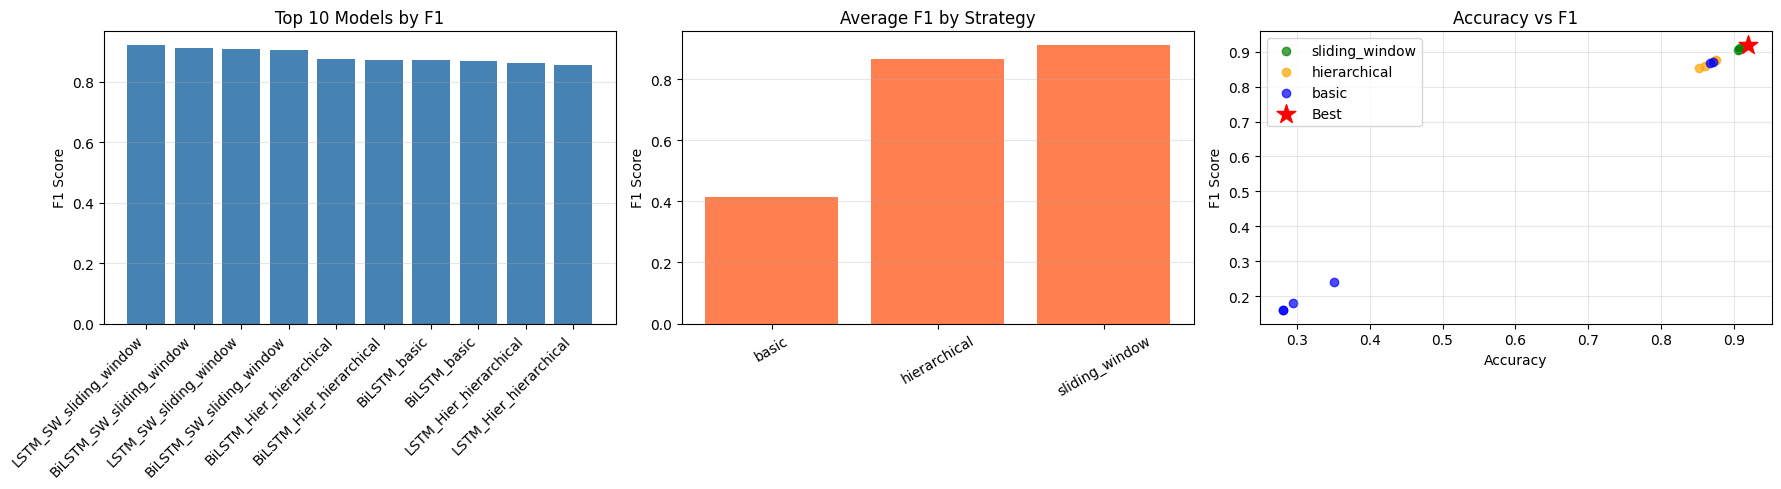


✅ Saved: visualization_results/model_comparison.png

TOP 5 MODELS (by F1 Score)

BẢNG TỔNG KẾT TẤT CẢ CÁC TRƯỜNG HỢP
Embedding                    Model       Strategy Accuracy Precision Recall     F1
    glove   LSTM_SW_sliding_window sliding_window   0.9200    0.9210 0.9200 0.9201
 skipgram BiLSTM_SW_sliding_window sliding_window   0.9089    0.9138 0.9089 0.9095
 skipgram   LSTM_SW_sliding_window sliding_window   0.9078    0.9076 0.9078 0.9075
    glove BiLSTM_SW_sliding_window sliding_window   0.9056    0.9059 0.9056 0.9053
    glove BiLSTM_Hier_hierarchical   hierarchical   0.8756    0.8780 0.8756 0.8759
 skipgram BiLSTM_Hier_hierarchical   hierarchical   0.8733    0.8782 0.8733 0.8728
 skipgram             BiLSTM_basic          basic   0.8711    0.8734 0.8711 0.8708
    glove             BiLSTM_basic          basic   0.8678    0.8728 0.8678 0.8674
    glove   LSTM_Hier_hierarchical   hierarchical   0.8611    0.8611 0.8611 0.8603
 skipgram   LSTM_Hier_hierarchical   hierarchical   

In [16]:
print("\n" + "="*80)
print("RESULTS VISUALIZATION")
print("="*80)

output_dir = "visualization_results"
os.makedirs(output_dir, exist_ok=True)

all_combos = []
for emb_name, method_results in all_results.items():
    for method_name, metrics in method_results.items():
        all_combos.append({
            "embedding": emb_name,
            "model":     method_name,
            "method":    metrics.get("strategy", "unknown"),
            "accuracy":  metrics.get("test_acc", 0),
            "precision": metrics.get("test_precision", 0),
            "recall":    metrics.get("test_recall", 0),
            "f1":        metrics.get("test_f1", 0)
        })

comparison_df = pd.DataFrame(all_combos).sort_values("f1", ascending=False)
best_row = comparison_df.iloc[0]

print(f"\n✅ Best Model: {best_row['model']} | Embedding: {best_row['embedding']} | "
      f"Method: {best_row['method']}")
print(f"   Accuracy={best_row['accuracy']:.4f} | Precision={best_row['precision']:.4f} | "
      f"Recall={best_row['recall']:.4f} | F1={best_row['f1']:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Top 10
ax1 = axes[0]
top10 = comparison_df.head(10)
ax1.bar(range(len(top10)), top10["f1"], color='steelblue')
ax1.set_xticks(range(len(top10)))
ax1.set_xticklabels(top10["model"], rotation=45, ha="right")
ax1.set_title("Top 10 Models by F1")
ax1.set_ylabel("F1 Score")
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Strategy avg
ax2 = axes[1]
method_avg = comparison_df.groupby("method")["f1"].mean()
ax2.bar(method_avg.index, method_avg.values, color='coral')
ax2.set_title("Average F1 by Strategy")
ax2.set_ylabel("F1 Score")
ax2.set_xticklabels(method_avg.index, rotation=30)
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Accuracy vs F1
ax3 = axes[2]
colors = {'basic': 'blue', 'sliding_window': 'green', 'hierarchical': 'orange'}
for method in comparison_df['method'].unique():
    subset = comparison_df[comparison_df['method'] == method]
    ax3.scatter(subset["accuracy"], subset["f1"],
                label=method, color=colors.get(method, 'gray'), alpha=0.7)
ax3.scatter(best_row["accuracy"], best_row["f1"],
            s=200, marker="*", color='red', label="Best", zorder=5)
ax3.set_xlabel("Accuracy")
ax3.set_ylabel("F1 Score")
ax3.legend()
ax3.set_title("Accuracy vs F1")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "model_comparison.png"), dpi=300)
plt.show()
print(f"\n✅ Saved: {output_dir}/model_comparison.png")
print("\nTOP 5 MODELS (by F1 Score)")
# ─── Bảng tổng kết tất cả các trường hợp ───────────────────────────────────
print("\n" + "="*80)
print("BẢNG TỔNG KẾT TẤT CẢ CÁC TRƯỜNG HỢP")
print("="*80)
summary_cols = ["embedding", "model", "method", "accuracy", "precision", "recall", "f1"]
summary_df = comparison_df[summary_cols].copy()
summary_df.columns = ["Embedding", "Model", "Strategy", "Accuracy", "Precision", "Recall", "F1"]
for col in ["Accuracy", "Precision", "Recall", "F1"]:
    summary_df[col] = summary_df[col].map(lambda x: f"{x:.4f}")
print(summary_df.to_string(index=False))
print("\n" + "="*80)
print(f"Tổng số cấu hình: {len(summary_df)}")
print("="*80)


DETAILED EVALUATION - BEST MODEL

✅ Best Model: LSTM_SW_sliding_window | Embedding: glove
   F1=0.9201 | Acc=0.9200


Predicting:   0%|          | 0/8 [00:00<?, ?it/s]


CLASSIFICATION REPORT
              precision    recall  f1-score   support

   cong-nghe     0.9292    0.8898    0.9091       236
  kinh-doanh     0.8608    0.9189    0.8889       222
    the-gioi     0.9302    0.8969    0.9132       223
    the-thao     0.9640    0.9772    0.9705       219

    accuracy                         0.9200       900
   macro avg     0.9210    0.9207    0.9204       900
weighted avg     0.9210    0.9200    0.9201       900



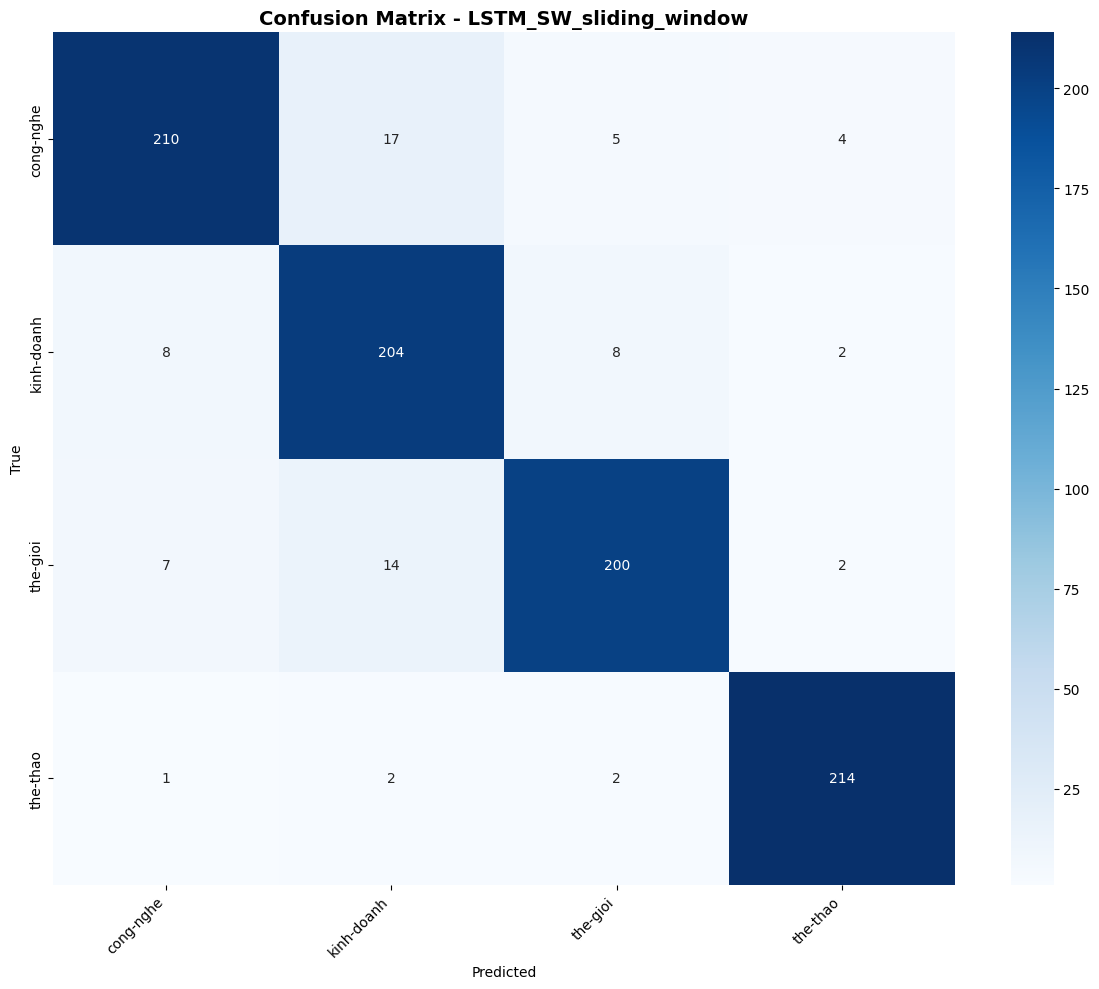


PER-CLASS METRICS:
     Class  Precision   Recall  F1-Score  Support
  the-thao   0.963964 0.977169  0.970522      219
  the-gioi   0.930233 0.896861  0.913242      223
 cong-nghe   0.929204 0.889831  0.909091      236
kinh-doanh   0.860759 0.918919  0.888889      222

Total Errors: 72 / 900 (8.00%)

Top 10 Most Confused Pairs:
      True  Predicted  Count
 cong-nghe kinh-doanh     17
  the-gioi kinh-doanh     14
kinh-doanh   the-gioi      8
kinh-doanh  cong-nghe      8
  the-gioi  cong-nghe      7
 cong-nghe   the-gioi      5
 cong-nghe   the-thao      4
kinh-doanh   the-thao      2
  the-gioi   the-thao      2
  the-thao kinh-doanh      2

✅ Evaluation results saved to: evaluation_results/


In [17]:
print("\n" + "="*80)
print("DETAILED EVALUATION - BEST MODEL")
print("="*80)

# Find best model
best_f1         = 0
best_embedding  = None
best_model_name = None
best_model_obj  = None

for emb_name, models in all_results.items():
    for model_name, metrics in models.items():
        if metrics['test_f1'] > best_f1:
            best_f1         = metrics['test_f1']
            best_embedding  = emb_name
            best_model_name = model_name
            best_model_obj  = metrics['model']

print(f"\n✅ Best Model: {best_model_name} | Embedding: {best_embedding}")
print(f"   F1={best_f1:.4f} | Acc={all_results[best_embedding][best_model_name]['test_acc']:.4f}")

strategy    = all_results[best_embedding][best_model_name]['strategy']
test_loader = dataloaders_dict[best_embedding][strategy]['test']

all_preds, all_labels, all_probs = get_predictions(best_model_obj, test_loader, device)

eval_output = "evaluation_results"
os.makedirs(eval_output, exist_ok=True)

class_names = label_encoder.classes_
report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)
print(report)

with open(os.path.join(eval_output, "classification_report.txt"), 'w', encoding='utf-8') as f:
    f.write(f"Best Model: {best_model_name}\nEmbedding: {best_embedding}\n"
            f"Strategy: {strategy}\n\n{report}")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(eval_output, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

# Per-class metrics
precision, recall, f1_arr, support = precision_recall_fscore_support(
    all_labels, all_preds, average=None
)
per_class_df = pd.DataFrame({
    'Class': class_names, 'Precision': precision,
    'Recall': recall, 'F1-Score': f1_arr, 'Support': support
}).sort_values('F1-Score', ascending=False)
print("\nPER-CLASS METRICS:")
print(per_class_df.to_string(index=False))
per_class_df.to_csv(os.path.join(eval_output, 'per_class_metrics.csv'), index=False)

# Error analysis
errors     = all_preds != all_labels
num_errors = errors.sum()
print(f"\nTotal Errors: {num_errors:,} / {len(all_labels):,} ({num_errors/len(all_labels)*100:.2f}%)")

confusion_pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({'True': class_names[i], 'Predicted': class_names[j], 'Count': cm[i, j]})
if confusion_pairs:
    conf_df = pd.DataFrame(confusion_pairs).sort_values('Count', ascending=False)
    print("\nTop 10 Most Confused Pairs:")
    print(conf_df.head(10).to_string(index=False))
    conf_df.to_csv(os.path.join(eval_output, 'confusion_pairs.csv'), index=False)

print(f"\n✅ Evaluation results saved to: {eval_output}/")

In [18]:
print("\n" + "="*80)
print("SAVING BEST MODEL AND ARTIFACTS")
print("="*80)

save_dir = "best_model"
os.makedirs(save_dir, exist_ok=True)

if best_model_obj is not None:
    # Xử lý DataParallel khi lưu
    m = best_model_obj.module if isinstance(best_model_obj, nn.DataParallel) else best_model_obj

    torch.save(m.state_dict(),
               os.path.join(save_dir, f"best_model_state_{best_model_name}.pth"))
    torch.save(m,
               os.path.join(save_dir, f"best_model_full_{best_model_name}.pth"))

    model_metadata = {
        'model_name':   best_model_name,
        'embedding':    best_embedding,
        'strategy':     strategy,
        'architecture': {
            'hidden_dim':     RNN_CONFIG['hidden_dim'],
            'num_layers':     RNN_CONFIG['num_layers'],
            'dropout':        RNN_CONFIG['dropout'],
            'vocab_size':     embeddings_dict[best_embedding]['vocab_size'],
            'embedding_dim':  embeddings_dict[best_embedding]['dim'],
            'num_classes':    num_classes
        },
        'test_metrics': {
            'accuracy': float(all_results[best_embedding][best_model_name]['test_acc']),
            'f1_score': float(best_f1),
            'loss':     float(all_results[best_embedding][best_model_name]['test_loss'])
        },
        'training_config': {k: v for k, v in RNN_CONFIG.items()},
        'device':     str(device),
        'amp_used':   torch.cuda.is_available(),
        'timestamp':  datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    with open(os.path.join(save_dir, "model_metadata.json"), 'w') as f:
        json.dump(model_metadata, f, indent=2, ensure_ascii=False)

    with open(os.path.join(save_dir, "label_encoder.pkl"), 'wb') as f:
        pickle.dump(label_encoder, f)

    with open(os.path.join(save_dir, f"word2idx_{best_embedding}.pkl"), 'wb') as f:
        pickle.dump(embeddings_dict[best_embedding]['word2idx'], f)

    torch.save(embeddings_dict[best_embedding]['embedding_matrix'],
               os.path.join(save_dir, f"embedding_matrix_{best_embedding}.pt"))

    results_comparison = []
    for emb_name, models in all_results.items():
        for model_name, metrics in models.items():
            results_comparison.append({
                'embedding':      emb_name,
                'model':          model_name,
                'strategy':       metrics['strategy'],
                'test_accuracy':  float(metrics['test_acc']),
                'test_f1':        float(metrics['test_f1']),
                'test_loss':      float(metrics['test_loss']),
                'num_params':     metrics.get('num_params', 0)
            })

    results_df = pd.DataFrame(results_comparison).sort_values('test_f1', ascending=False)
    results_df.to_csv(os.path.join(save_dir, "all_results_comparison.csv"), index=False)

    with open(os.path.join(save_dir, "all_results.json"), 'w') as f:
        json.dump(results_comparison, f, indent=2, ensure_ascii=False)

    with open(os.path.join(save_dir, "training_histories.pkl"), 'wb') as f:
        pickle.dump(all_histories, f)

    # Summary
    with open(os.path.join(save_dir, "SUMMARY.txt"), 'w', encoding='utf-8') as f:
        f.write("="*80 + "\n")
        f.write("VIETNAMESE TEXT CLASSIFICATION - TRAINING SUMMARY\n")
        f.write("="*80 + "\n\n")
        f.write(f"Generated : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Device    : {device}\n")
        f.write(f"AMP (Mixed Precision): {torch.cuda.is_available()}\n\n")
        f.write(f"BEST MODEL\n{'-'*40}\n")
        f.write(f"Model    : {best_model_name}\n")
        f.write(f"Embedding: {best_embedding}\n")
        f.write(f"Strategy : {strategy}\n")
        f.write(f"Accuracy : {all_results[best_embedding][best_model_name]['test_acc']:.4f}\n")
        f.write(f"F1 Score : {best_f1:.4f}\n\n")
        f.write("TOP 5 MODELS\n" + "-"*80 + "\n")
        for i, row in results_df.head(5).iterrows():
            f.write(f"  {row['model']:30s} {row['embedding']:12s} "
                    f"{row['strategy']:15s} F1={row['test_f1']:.4f} "
                    f"Acc={row['test_accuracy']:.4f}\n")

    print(f"\nFiles saved in '{save_dir}/':")
    total_size = 0
    for fname in sorted(os.listdir(save_dir)):
        size = os.path.getsize(os.path.join(save_dir, fname)) / 1024
        total_size += size
        print(f"   {fname:<50} {size:>10.2f} KB")
    print(f"\nTotal size: {total_size/1024:.2f} MB")

print("\n" + "="*80)
print("✅ COMPLETE! All files saved.")
print("="*80)


SAVING BEST MODEL AND ARTIFACTS

Files saved in 'best_model/':
   SUMMARY.txt                                              0.94 KB
   all_results.json                                         3.27 KB
   all_results_comparison.csv                               1.44 KB
   best_model_full_LSTM_SW_sliding_window.pth           34343.58 KB
   best_model_state_LSTM_SW_sliding_window.pth          34341.65 KB
   embedding_matrix_glove.pt                            32961.83 KB
   label_encoder.pkl                                        0.28 KB
   model_metadata.json                                      0.69 KB
   training_histories.pkl                                   4.47 KB
   word2idx_glove.pkl                                     330.21 KB

Total size: 99.60 MB

✅ COMPLETE! All files saved.
